In [1]:
import pandas as pd

In [17]:
import os
import json
import requests
from datetime import datetime, timedelta, timezone
import numpy as np

# Load the API token from config.json
with open('config.json', 'r') as f:
    config = json.load(f)

#api_token = config['osf_service']['api_key']  

# Preparing and prepping datafiles for merging
1. Annotinder files

In [4]:
file_names = [
    "annotations_95_AnnoBias job final, set 1.csv.csv",
    "annotations_96_AnnoBias job final, set 2.csv.csv",
    "annotations_97_AnnoBias job final, set 3.csv.csv",
    "annotations_98_AnnoBias job final, set 4.csv.csv",
    "annotations_99_AnnoBias job final, set 5.csv.csv",
    "annotations_100_AnnoBias job final, set 6.csv.csv"
]

dataframes = []

for idx, file in enumerate(file_names, start=1):
    df = pd.read_csv(f"data/AnnoTinder_data_exports/{file}")  
    
    # Add a "condition" column based on the file number
    df['condition_AT'] = idx    
    dataframes.append(df)  # Append the DataFrame to the list

annotinder_df = pd.concat(dataframes, ignore_index=True)
annotinder_df['uid'] = annotinder_df['coder']

2. Twitter data

In [7]:
X_data = pd.read_csv('data/X_data/final_stratified_immigration.csv')
X_data['tweet_id'] = X_data['tweet_id'].astype(str)

3. Qualtrics data 

In [10]:
before = pd.read_csv('data/Qualtrics_data_exports/before.csv', skiprows=[1,2])
after = pd.read_csv('data/Qualtrics_data_exports/after.csv', skiprows=[1,2])
before_before = pd.read_csv('data/Qualtrics_data_exports/start_survey.csv', skiprows=[1,2])
before_after = pd.merge(before, after, on='uid')
before_before['StartDate_First'] = before_before['StartDate']

In [14]:
print(len(before_after))
qualtrics_merged = pd.merge(before_before, before_after, on='psid')
print(len(qualtrics_merged))

len(before_before)
len(set(qualtrics_merged['uid']))
len(set(qualtrics_merged['psid']))
len(set(qualtrics_merged['dsc']))

1585
1560


1546

Merge AnnoTinder and Twitter data and Qualtrics data

In [13]:
#Trim the first 15 digits from both columns – This is because: The issue was that when reading the CSV file, the tweet_id was treated as a number. Since it is such a large value, it cannot be exactly represented as a double. This results in a loss of accuracy when converting it to a string."
annotinder_df['unit_id_15'] = annotinder_df['unit_id'].str[:15]
list(annotinder_df['unit_id_15'].value_counts(ascending=False))

X_data['tweet_id_15'] = X_data['tweet_id'].str[:15]

# Filtreren van X_data_with_ids zodat alleen de rijen overblijven die een match hebben met unit_id_15 in annotinder_df
matching_rows = X_data[X_data['tweet_id_15'].isin(annotinder_df['unit_id_15'])]

# Merge all columns from X_data with annotinder_df based on tweet_id_15 and unit_id_15
annotinder_twitter = annotinder_df.merge(matching_rows, 
                                         left_on='unit_id_15', right_on='tweet_id_15', 
                                         how='left')

In [30]:
df = pd.merge(annotinder_twitter, qualtrics_merged, on='uid', how='left')

In [31]:

# Function to handle NaN or non-string values and calculate differences
def calculate_time_differences_fixed_mdt(start_dates, time_answers):
    differences = []
    
    for start, answer in zip(start_dates, time_answers):
        # Ensure both start and answer are strings and handle missing values
        if pd.isnull(start) or pd.isnull(answer):
            differences.append(None)  # Skip if any value is missing
            continue
        
        try:
            # Parse StartDate_y (assuming it's in MDT, which is UTC-6)
            start_dt = datetime.strptime(str(start), '%Y-%m-%d %H:%M:%S')
            
            # Convert MDT to UTC by adding 6 hours, and make it timezone-aware (UTC)
            start_dt_utc = (start_dt + timedelta(hours=6)).replace(tzinfo=timezone.utc)
            
            # Parse time_answer (already in UTC, so timezone-aware)
            answer_dt = datetime.strptime(str(answer), '%Y-%m-%dT%H:%M:%S.%fZ').replace(tzinfo=timezone.utc)
            
            # Calculate the time difference in minutes
            time_diff = (answer_dt - start_dt_utc).total_seconds() / 60
            differences.append(time_diff)
        except Exception as e:
            differences.append(None)  # Handle errors and malformed data
    
    return differences


time_differences = calculate_time_differences_fixed_mdt(df['StartDate_First'], df['time_answer'])

df['time_difference'] = time_differences

df = df.sort_values(by=['psid', 'time_answer'])
last_observation = df.groupby('psid').last().reset_index()
last_observation[['psid', 'time_difference']]

,psid,time_difference
0,_1KUVoNGiAg-FXLYMSdwbQ**,26.213683
1,_1KUVoNGiAg-GTXuLE-E1g**,158.219017
2,_1KUVoNGiAg-ODrdbezcMw**,30.623817
3,_1KUVoNGiAg-d35IGIrcEA**,32.588867
4,_1KUVoNGiAg0OjdoLHQ17Q**,228.668833
...,...,...
1427,_1KUVoNGiAjyy-x0jm2qrw**,24.002267
1428,_1KUVoNGiAjz-R_IQlXnww**,16.613133
1429,_1KUVoNGiAjz9z84bgIj8Q**,22.783517
1430,_1KUVoNGiAjzcvail1lDPA**,24.716950


## Compute variables

In [32]:

# Sample likert_mapping (you have already defined this)
likert_mapping = {
    "Geheel onwaarschijnlijk": 1,
    "Onwaarschijnlijk": 2,
    "Niet waarschijnlijk, maar ook niet onwaarschijnlijk": 3,
    "Waarschijnlijk": 4,
    "Zeer waarschijnlijk": 5
}

# Assuming df is your DataFrame containing individual data

# Step 1: Map Likert responses to numeric values for each party
party_columns = ['PolCongr_1', 'PolCongr_2', 'PolCongr_3', 'PolCongr_4', 'PolCongr_5', 
                 'PolCongr_6', 'PolCongr_7', 'PolCongr_8', 'PolCongr_9', 'PolCongr_10',
                 'PolCongr_11', 'PolCongr_12', 'PolCongr_13', 'PolCongr_14', 'PolCongr_15']

# Map Likert scale responses to numeric values for all relevant columns
for party in party_columns:
    df[party] = df[party].map(likert_mapping)

# Step 2: Create a mapping from party names to their corresponding PolCongr_* columns
party_to_column_mapping = {
    'PVV': 'PolCongr_1',
    'GroenLinks-PvdA': 'PolCongr_2',  # GL-PvdA combined
    'VVD': 'PolCongr_3',
    'Nieuw Sociaal Contract': 'PolCongr_4',
    'D66': 'PolCongr_5',
    'BBB': 'PolCongr_6',
    'CDA': 'PolCongr_7',
    'SP': 'PolCongr_8',
    'DENK': 'PolCongr_9',
    'Partij voor de Dieren': 'PolCongr_10',
    'Forum voor Democratie': 'PolCongr_11',
    'SGP': 'PolCongr_12',
    'ChristenUnie': 'PolCongr_13',
    'Volt': 'PolCongr_14',
    'Ja21': 'PolCongr_15'
}


# Step 3: Combine the relevant parties ('GroenLinks', 'PvdA', 'GroenLinks-PvdA') into a single group
df['normalized_party'] = df['normalized_party'].replace({
    'GroenLinks': 'GroenLinks-PvdA',  # Combine GroenLinks and PvdA into GroenLinks-PvdA
    'PvdA': 'GroenLinks-PvdA'
})


# Step 4: Calculate the score for the normalized party (single numeric score)


def calculate_party_score(row):
    normalized_party = row['normalized_party']
    
    # Look up the column corresponding to the normalized party
    normalized_party_column = party_to_column_mapping.get(normalized_party)
    
    if normalized_party_column:
        # Return the score from the corresponding column for the normalized party
        return row[normalized_party_column]
    else:
        return None

# Step 6: Apply the function to calculate the score for each participant
df['vote_likelihood_score'] = df.apply(calculate_party_score, axis=1)

# Step 7: Check the updated DataFrame with the vote likelihood score
#df[['normalized_party', 'vote_likelihood_score']].tail(50)

In [40]:
df['vote_likelihood_score'].value_counts()

1.0    59500
2.0    30536
3.0    25420
4.0    16832
5.0    10036
Name: vote_likelihood_score, dtype: int64

In [58]:
df[['normalized_party', 'vote_likelihood_score']].tail(3)

,normalized_party,vote_likelihood_score
115807,SP,2.0
115808,SP,2.0
115809,SP,2.0


In [50]:

## Delete cases

## everything before the Soft Launch


# Convert the time_question column to datetime
df["time_question"] = pd.to_datetime(df["time_question"], format="%Y-%m-%dT%H:%M:%S.%fZ")

# Define the cutoff date
cutoff_date = datetime(2024, 10, 14)

# Filter out rows where time_question is earlier than the cutoff date
df= df[df["time_question"] >= cutoff_date]

# Drop rows where 'Condition' has NaN values
df = df.dropna(subset=['Condition'])
df = df.dropna(subset=['dsc'])

## Remove participants who either did not complete the coding job or did multiple rounds 

df['uid'].value_counts()

uid_counts = df['uid'].value_counts()
# Filter for those uids that have exactly 131 observations
uids_with_131 = uid_counts[uid_counts == 131].index

# Filter the original DataFrame to keep only those uids
df = df[df['uid'].isin(uids_with_131)]

pd.crosstab(df['condition_AT'], df['Condition'])

Condition,1.0,2.0,3.0,4.0,5.0,6.0
condition_AT,,,,,,
1,24759,0,0,0,0,0
2,0,26855,0,0,0,0
3,0,0,24366,0,0,0
4,0,0,0,25414,0,0
5,0,0,0,0,24366,0
6,0,0,0,0,0,24890


In [45]:
df['uid'].nunique()
df['uid'].nunique()
df[['uid', 'jobset']].nunique()

,uid,jobsets_count


In [51]:
# Define the mapping for instructions
instruction_mapping = {
    1: "no instructions",
    2: "general instructions",
    3: "tailored instructions",
    4: "no instructions",
    5: "general instructions",
    6: "tailored instructions",
}

# Convert condition to integers before mapping
df["instruction_type"] = df["Condition"].astype(int).map(instruction_mapping)

# Define whether the condition includes author handle
df["source_shown"] = df["Condition"].astype(int).apply(
    lambda x: 0 if x in [1, 2, 3] else 1)

In [52]:
df['instruction_type'].value_counts()
df['source_shown'].value_counts()

0    75980
1    74670
Name: source_shown, dtype: int64

In [53]:
df['Ideology']
df['text']

129432                                                  NaN
129445                                                  NaN
129446                                                  NaN
129447                                                  NaN
129448                                                  NaN
                                ...                        
115793    Stop het hapsnapbeleid bij de opvang van asiel...
115806    Onze initiatiefwet Verdringingstoets is in de ...
115807    Onze initiatiefwet Verdringingstoets is in de ...
115808    Onze initiatiefwet Verdringingstoets is in de ...
115809    Onze initiatiefwet Verdringingstoets is in de ...
Name: text, Length: 150650, dtype: object

In [215]:
df['coder_id']
df['variable'].value_counts()

len(set(df['uid']))

len(df['coder_id'].unique())
len(df['dsc'].unique())

nan_count = df['Condition'].isna().sum()
print(f"Number of NaN values in 'Condition': {nan_count}")

Number of NaN values in 'Condition': 3515


In [56]:
# Encode the stance as an ordinal variable
scale_mapping = {
    "Helemaal niet waar": 1,
    "Gedeeltelijk niet waar": 2,
    "Neutraal": 3,
    "Gedeeltelijk waar": 4,
    "Helemaal waar": 5
}

df['value_nan'] = df['value'].replace(['Waar', 'Niet waar', 'confirmed'], np.nan)

# Map the remaining categories to a numeric scale
df['value_scaled'] = df['value_nan'].map(scale_mapping)
# Check the updated DataFrame
print(df[['value', 'value_scaled']].tail())

                         value  value_scaled
115793                Neutraal           3.0
115806       Gedeeltelijk waar           4.0
115807  Gedeeltelijk niet waar           2.0
115808       Gedeeltelijk waar           4.0
115809                Neutraal           3.0


In [64]:
df[df['variable'] == 'stellingen.political_stance'][['Ideology', 'normalized_party','PolOrient_1']]

df['instruction_type'].value_counts()
df['source_shown'].value_counts()

0    75980
1    74670
Name: source_shown, dtype: int64

In [65]:
df['variable'].value_counts()

stellingen.political_stance    34500
stellingen.sentiment           34500
stellingen.toxic               34500
stellingen.misinformation      34500
confirm                         3450
political_stance_training       2300
sentiment_training              2300
toxic_training                  2300
misinformation_training         2300
Name: variable, dtype: int64

In [362]:
#list(df)

In [76]:
df_clean = df.reset_index(drop=True)

df_clean = df.dropna(subset=['value_scaled', 'vote_likelihood_score', 'PolOrient_1', 'source_shown', 'dsc', 'coder_id', 'tweet_id'])
#df_clean

# Fit the model
model = smf.mixedlm(
    "value_scaled ~ vote_likelihood_score * source_shown + dsc + instruction_type",
    data=df_clean[df_clean['variable'] == 'stellingen.toxic'],
    groups="coder_id",  # Grouping variable
    re_formula="~1"
)

# Fit the model and summarize the results
result = model.fit()
print(result.summary())


                       Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         value_scaled
No. Observations:           32468           Method:                     REML        
No. Groups:                 1150            Scale:                      1.0581      
Min. group size:            24              Log-Likelihood:             -48702.4230 
Max. group size:            30              Converged:                  Yes         
Mean group size:            28.2                                                    
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  2.731    0.060 45.274 0.000  2.612  2.849
instruction_type[T.no instructions]       -0.041    0.061 -0.678 0.498 -0.161  0.078
inst

<Axes: >

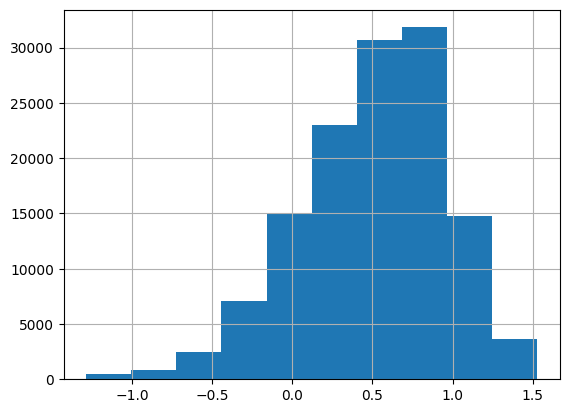

In [77]:
df_clean['dsc'].hist()

In [86]:
import pandas as pd
import statsmodels.formula.api as smf

# Example dataset
# df contains columns: participant_id, outcome_var, tweet_char_1, tweet_char_2, participant_char_1

# Fit a linear mixed-effects model
model = smf.mixedlm(
    "value_scaled ~ vote_likelihood_score * source_shown",
    data=df_clean[df_clean['variable'] == 'stellingen.toxic'],
    groups="coder_id",  # Grouping variable
    re_formula="~1"
)

result = model.fit()

# Summarize the model
print(result.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       value_scaled
No. Observations:        32468         Method:                   REML        
No. Groups:              1150          Scale:                    1.0581      
Min. group size:         24            Log-Likelihood:           -48700.3547 
Max. group size:         30            Converged:                Yes         
Mean group size:         28.2                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           2.670    0.041 65.420 0.000  2.590  2.750
vote_likelihood_score               0.002    0.010  0.256 0.798 -0.016  0.021
source_shown                        0.124    0.058  2.125 0.034  0.010  0.238
vote_l

In [87]:
import pandas as pd
import statsmodels.formula.api as smf

# Example dataset
# df contains columns: participant_id, outcome_var, tweet_char_1, tweet_char_2, participant_char_1

# Fit a linear mixed-effects model
model = smf.mixedlm(
    "value_scaled ~  vote_likelihood_score  *  source_shown ",
    data=df_clean[df_clean['variable'] == 'stellingen.misinformation'],
    groups="coder_id",  # Grouping variable
    re_formula="~1"
)

result = model.fit()

# Summarize the model
print(result.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       value_scaled
No. Observations:        32468         Method:                   REML        
No. Groups:              1150          Scale:                    1.0518      
Min. group size:         24            Log-Likelihood:           -48505.4241 
Max. group size:         30            Converged:                Yes         
Mean group size:         28.2                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           2.783    0.038 72.920 0.000  2.708  2.857
vote_likelihood_score              -0.024    0.010 -2.545 0.011 -0.043 -0.006
source_shown                        0.219    0.054  4.016 0.000  0.112  0.326
vote_l

/tmp/ipykernel_2004852/2697841857.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  predictions = predictions.append({
/tmp/ipykernel_2004852/2697841857.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  predictions = predictions.append({
/tmp/ipykernel_2004852/2697841857.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  predictions = predictions.append({
/tmp/ipykernel_2004852/2697841857.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  predictions = predictions.append({
/tmp/ipykernel_2004852/2697841857.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use panda

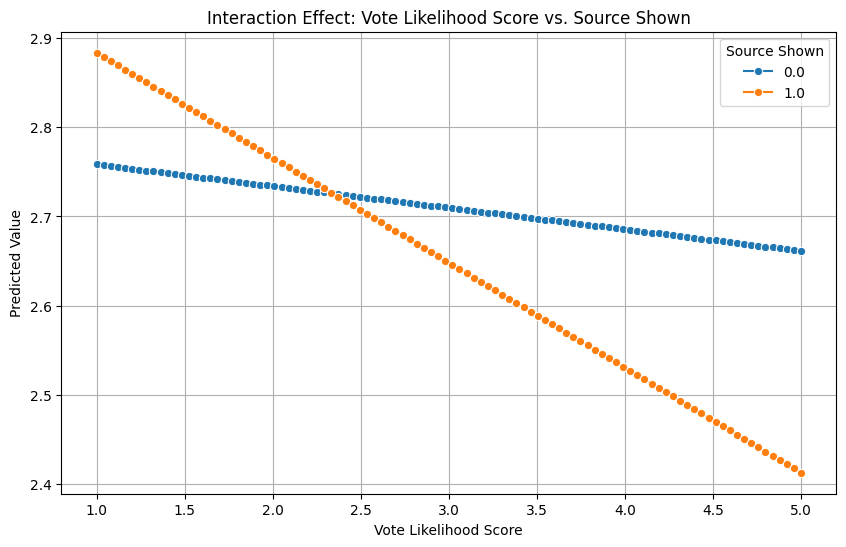

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Get the fitted model's parameters
params = result.params

# Create a grid of values for vote_likelihood_score and source_shown
vote_likelihood_scores = np.linspace(df_clean['vote_likelihood_score'].min(), df_clean['vote_likelihood_score'].max(), 100)
source_showns = df_clean['source_shown'].unique()

# Prepare a DataFrame to store the predictions
predictions = pd.DataFrame(columns=["vote_likelihood_score", "source_shown", "predicted_value"])

for source in source_showns:
    for score in vote_likelihood_scores:
        # Create a row for each combination of source_shown and vote_likelihood_score
        new_data = pd.DataFrame({
            'vote_likelihood_score': [score],
            'source_shown': [source]
        })
        
        # Predict the value_scaled for this combination
        pred = result.predict(new_data)
        
        # Append the prediction to the DataFrame
        predictions = predictions.append({
            "vote_likelihood_score": score,
            "source_shown": source,
            "predicted_value": pred[0]
        }, ignore_index=True)

# Plot the interaction
plt.figure(figsize=(10, 6))
sns.lineplot(data=predictions, x='vote_likelihood_score', y='predicted_value', hue='source_shown', marker='o')
plt.title('Interaction Effect: Vote Likelihood Score vs. Source Shown')
plt.xlabel('Vote Likelihood Score')
plt.ylabel('Predicted Value')
plt.legend(title='Source Shown')
plt.grid(True)
plt.show()


In [508]:
import pandas as pd
import statsmodels.formula.api as smf

# Example dataset
# df contains columns: participant_id, outcome_var, tweet_char_1, tweet_char_2, participant_char_1

# Fit a linear mixed-effects model
model = smf.mixedlm(
    "value_scaled ~ PolOrient_1 + vote_likelihood_score + source_shown + instruction_type * dsc ",
    data=df_clean[df_clean['variable'] == 'stellingen.toxic'],
    groups="coder_id",  # Grouping variable
    re_formula="~1"
)

result = model.fit()

# Summarize the model
print(result.summary())

                         Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           value_scaled
No. Observations:           32576             Method:                       REML        
No. Groups:                 1154              Scale:                        1.0573      
Min. group size:            24                Log-Likelihood:               -48844.4567 
Max. group size:            30                Converged:                    Yes         
Mean group size:            28.2                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      2.512    0.088 28.451 0.000  2.339  2.685
instruction_type[T.no instructions]           -

[1.22391646 0.80824271 1.07713428 ... 0.70295745 0.73662644 0.51324018]
Number of NaN values in 'dsc': 0
['general instructions', 'tailored instructions', 'no instructions']
Categories (3, object): ['general instructions', 'no instructions', 'tailored instructions']
                         Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           value_scaled
No. Observations:           35776             Method:                       REML        
No. Groups:                 1248              Scale:                        1.3531      
Min. group size:            1                 Log-Likelihood:               -57648.5422 
Max. group size:            120               Converged:                    Yes         
Mean group size:            28.7                                                        
----------------------------------------------------------------------------------------
                                              C

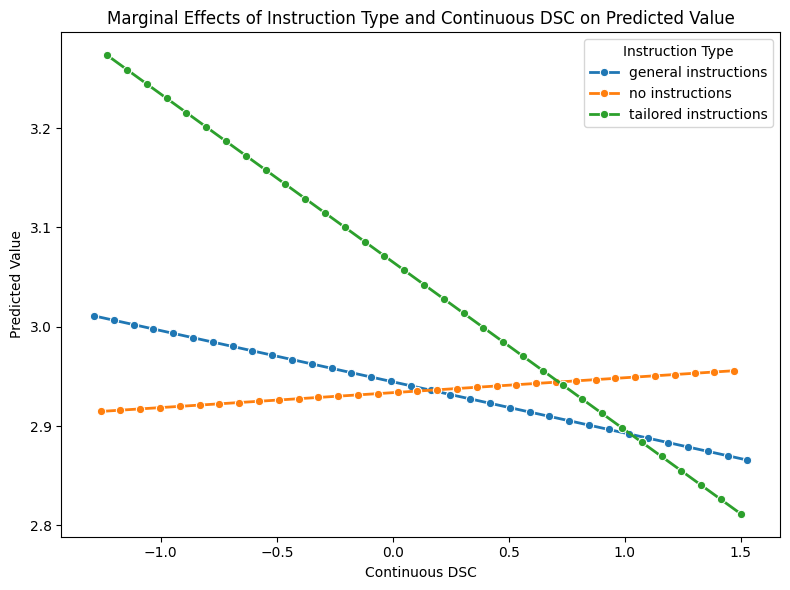

In [377]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Clean the dataset

# Check for non-numeric values in the 'dsc' column
print(df_clean['dsc'].unique())  # Look at unique values in the 'dsc' column

# Attempt to convert 'dsc' to numeric, invalid parsing will be turned into NaN
df_clean['dsc'] = pd.to_numeric(df_clean['dsc'], errors='coerce')

# Step 2: Check for any missing values (NaN) after conversion
print(f"Number of NaN values in 'dsc': {df_clean['dsc'].isna().sum()}")  # Count of NaN values in 'dsc'

# Optionally, drop rows with NaN in 'dsc' (you can also impute or handle them differently if needed)
df_clean = df_clean.dropna(subset=['dsc'])

# Step 3: Check 'instruction_type' for categorical issues
print(df_clean['instruction_type'].unique())  # Unique values in 'instruction_type'

# If 'instruction_type' is not categorical, convert it
df_clean['instruction_type'] = df_clean['instruction_type'].astype('category')

# Step 4: Fit the mixed effects model
# Use the continuous 'dsc' without binning
model = smf.mixedlm(
    "value_scaled ~ PolOrient_1 + source_shown + instruction_type * dsc",  # Use continuous 'dsc'
    data=df_clean[df_clean['variable'] == 'stellingen.sentiment'],  # Filter for 'stellingen.toxic' variable
    groups="coder_id",  # Grouping by coder_id (random intercepts)
    re_formula="~1"  # Random intercepts for participants (coder_id)
)

# Fit the model and display the summary
result = model.fit()
print(result.summary())

# Step 5: Compute the Marginal Effects for Continuous 'dsc'
# Generate a range of 'dsc' values for prediction
dsc_range = np.linspace(df_clean['dsc'].min(), df_clean['dsc'].max(), 100)

# Create a DataFrame for all combinations of 'instruction_type' and 'dsc' values
# We repeat instruction_type to match the length of dsc_range
instruction_types = np.tile(df_clean['instruction_type'].cat.categories, len(dsc_range) // len(df_clean['instruction_type'].cat.categories) + 1)
instruction_types = instruction_types[:len(dsc_range)]  # Slice to match length of dsc_range

# Create the DataFrame with dsc and instruction_type combinations
marginal_data = pd.DataFrame({
    'dsc': dsc_range,
    'instruction_type': instruction_types
})

# Set the other predictors (PolOrient_1 and source_shown) to their mean values
marginal_data['PolOrient_1'] = df_clean['PolOrient_1'].mean()
marginal_data['source_shown'] = df_clean['source_shown'].mean()

# We use a fixed coder_id (first one, for example) to keep it constant
marginal_data['coder_id'] = df_clean['coder_id'].unique()[0]

# Get the predicted values from the model
predicted_values = result.predict(marginal_data)

# Add the predicted values to the DataFrame
marginal_data['predicted_value'] = predicted_values

# Step 6: Visualize the Marginal Effects for Continuous 'dsc'
# Plot the marginal effects of the continuous 'dsc' variable on predicted value, grouped by 'instruction_type'
plt.figure(figsize=(8, 6))
sns.lineplot(
    x='dsc', y='predicted_value', hue='instruction_type', 
    data=marginal_data, marker='o', linewidth=2
)
plt.title('Marginal Effects of Instruction Type and Continuous DSC on Predicted Value')
plt.xlabel('Continuous DSC')
plt.ylabel('Predicted Value')
plt.legend(title='Instruction Type')
plt.tight_layout()

plt.show()


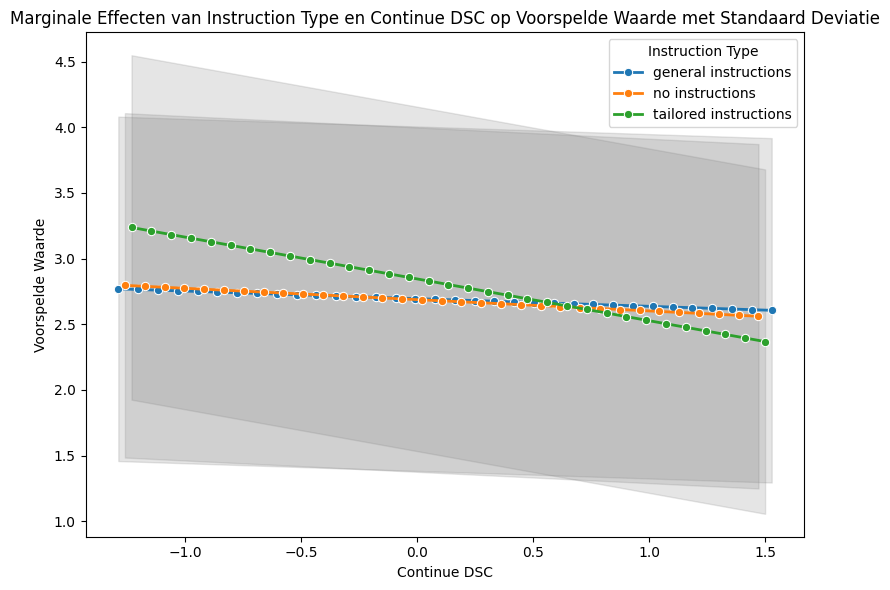

In [375]:
plt.figure(figsize=(8, 6))

# Teken de lijnplot voor de voorspelde waarden
sns.lineplot(
    x='dsc', y='predicted_value', hue='instruction_type', 
    data=marginal_data, marker='o', linewidth=2
)

# Voeg de schaduwgebieden toe voor de standaardfout (± 1 standaarddeviatie)
for instruction_type in marginal_data['instruction_type'].cat.categories:
    subset = marginal_data[marginal_data['instruction_type'] == instruction_type]
    
    # Schaduwgebied rond de lijn: transparantie verhoogd voor duidelijkheid
    plt.fill_between(subset['dsc'], 
                     subset['predicted_value'] - subset['std_dev'], 
                     subset['predicted_value'] + subset['std_dev'], 
                     alpha=0.2, color='grey')

# Titel en labels toevoegen
plt.title('Marginale Effecten van Instruction Type en Continue DSC op Voorspelde Waarde met Standaard Deviatie')
plt.xlabel('Continue DSC')
plt.ylabel('Voorspelde Waarde')
plt.legend(title='Instruction Type')

# Verbeteren van de lay-out voor meer ruimte
plt.tight_layout()

# Toon de grafiek
plt.show()
